# Human Activity Recognition from Smartphone Sensors

This notebook builds a classifier that recognizes what physical activity a
person is doing — walking, walking upstairs, walking downstairs, sitting,
standing, or lying down — from accelerometer and gyroscope readings on a
smartphone worn at the waist.

**Dataset.** The [UCI "Human Activity Recognition Using Smartphones"
dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones):
30 volunteers performed the six activities above while wearing a Samsung
Galaxy S II. The raw accelerometer and gyroscope signals were processed into
a **561-feature vector per time window** (time- and frequency-domain
statistics of the sensor signals), plus a `subject` identifier (1-30) and
the `Activity` label. The data is pre-split into a train set (21 subjects)
and a test set (9 subjects), with no subject appearing in both.

**Goal.** Train a classifier on the training subjects, evaluate it on the
held-out test subjects, and see how well sensor data alone can distinguish
these six activities. We train two variants of a multi-layer perceptron
(`sklearn.neural_network.MLPClassifier`) — one optimized with plain SGD, one
with Adam — and compare them.

**How to run this notebook.** See `README.md` for setup instructions. In
short: `pip install -r requirements.txt`, then `python download_data.py` to
fetch the dataset into `data/`, then run this notebook top to bottom.


## 1. Load the data

The dataset is not checked into this repository (it's ~65 MB). Run
`python download_data.py` from the repo root first — it downloads the
dataset from the UCI Machine Learning Repository and writes
`data/train.csv` and `data/test.csv` in the flat shape this notebook
expects (561 sensor feature columns + `subject` + `Activity`).


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.utils import shuffle
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# A small number of numpy/BLAS builds emit spurious "overflow"/"divide by
# zero encountered in matmul" RuntimeWarnings during MLP training on some
# platforms. They are cosmetic (weights stay well-bounded and results are
# stable/reproducible) so we silence just that specific message.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*")

# sklearn's ConvergenceWarning is useful signal (it tells us whether a
# solver reached its tolerance before hitting max_iter), but its default
# formatting prints the full local file path of the sklearn module that
# raised it. We check convergence explicitly after each fit below instead,
# so the raw warning (and the local path noise) is suppressed here.
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

sns.set_theme(style="whitegrid")
%matplotlib inline


In [2]:
DATA_DIR = Path("data")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

if not TRAIN_PATH.exists() or not TEST_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {TRAIN_PATH} and/or {TEST_PATH}.\n\n"
        "This notebook expects the UCI HAR dataset to already be downloaded "
        "into the data/ directory. From the repo root, run:\n\n"
        "    python download_data.py\n\n"
        "That script downloads the dataset from the UCI Machine Learning "
        "Repository and assembles data/train.csv and data/test.csv. See "
        "README.md for details."
    )

train_data = pd.read_csv(TRAIN_PATH)
test_data = pd.read_csv(TEST_PATH)

print(f"train_data: {train_data.shape[0]:,} rows x {train_data.shape[1]} columns")
print(f"test_data:  {test_data.shape[0]:,} rows x {test_data.shape[1]} columns")


train_data: 7,352 rows x 563 columns
test_data:  2,947 rows x 563 columns


## 2. Exploratory data analysis

Before modeling, a quick look at class balance, subject coverage, and
whether individual sensor features visibly separate the activities.


In [3]:
print("Missing values — train:", train_data.isnull().sum().sum())
print("Missing values — test: ", test_data.isnull().sum().sum())
print("\nSubjects in train:", train_data['subject'].nunique())
print("Subjects in test: ", test_data['subject'].nunique())
overlap = set(train_data['subject']) & set(test_data['subject'])
print("Subjects appearing in both splits:", len(overlap), "(expected: 0)")


Missing values — train: 0
Missing values — test:  0

Subjects in train: 21
Subjects in test:  9
Subjects appearing in both splits: 0 (expected: 0)


Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


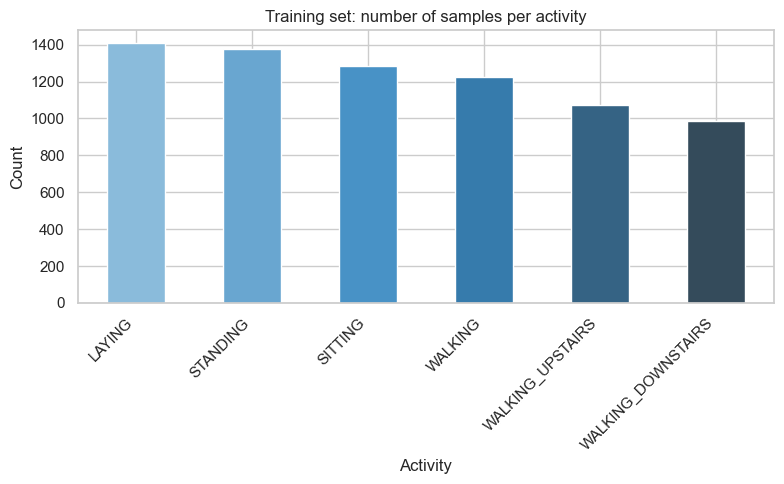

In [4]:
activity_counts = train_data['Activity'].value_counts()
print(activity_counts)

fig, ax = plt.subplots(figsize=(8, 5))
activity_counts.plot(kind='bar', ax=ax, color=sns.color_palette("Blues_d", len(activity_counts)))
ax.set_title("Training set: number of samples per activity")
ax.set_xlabel("Activity")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


The six classes are reasonably balanced (roughly 1,000-1,400 samples each),
so accuracy is a fair headline metric here — no class dominates the dataset.


In [5]:
# How many samples each subject contributed to each activity.
pd.crosstab(train_data['subject'], train_data['Activity'])


Activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
subject,,,,,,
1,50,47,53,95,49,53
3,62,52,61,58,49,59
5,52,44,56,56,47,47
6,57,55,57,57,48,51
7,52,48,53,57,47,51
8,54,46,54,48,38,41
11,57,53,47,59,46,54
14,51,54,60,59,45,54
15,72,59,53,54,42,48


Each subject performed each activity in a single continuous recording
session, so the crosstab shows how many sliding-window samples that session
produced — not a designed balance across subjects, which is why counts vary
subject to subject.

### Do the raw features actually separate activities?

As a sanity check, here's how three individual sensor features vary by
activity for a single subject. If a classifier is going to work, we'd
expect at least some raw features to already show separation between
activities like this.


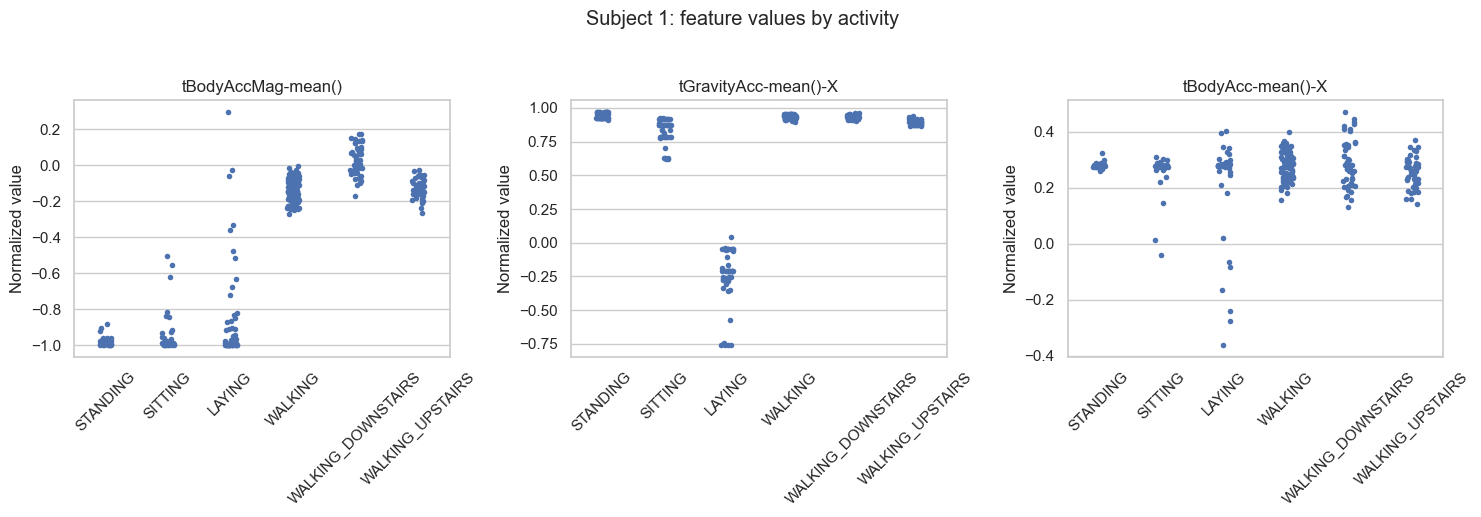

In [6]:
sub_01 = train_data.loc[train_data['subject'] == 1]

features_to_check = [
    "tBodyAccMag-mean()",     # overall body acceleration magnitude
    "tGravityAcc-mean()-X",   # phone orientation relative to gravity
    "tBodyAcc-mean()-X",      # raw body acceleration, X axis
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feature in zip(axes, features_to_check):
    sns.stripplot(x='Activity', y=feature, data=sub_01, jitter=True, ax=ax, size=4)
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Normalized value")
    ax.tick_params(axis='x', rotation=45)

fig.suptitle("Subject 1: feature values by activity", y=1.03)
plt.tight_layout()
plt.show()


`tBodyAccMag-mean()` cleanly separates the three dynamic activities
(walking variants, which cluster high) from the three static ones (sitting,
standing, laying, which cluster near zero). `tGravityAcc-mean()-X` in turn
separates laying (phone orientation changes when lying down) from
sitting/standing. That's a strong signal that a classifier trained on all
561 features should do well.


## 3. Preprocessing

- Drop `subject` from the modeling features (it's a person identifier, not
  a sensor reading, and using it would let the model "memorize" subjects
  instead of learning activity patterns).
- Shuffle the training rows — as loaded, they're grouped by subject and
  activity in blocks, which is a bad order to feed a model that could be
  sensitive to it.
- Label-encode `Activity` into integers 0-5. The encoder is **fit once on
  the training labels only**, then reused to transform the test labels.
  Fitting a separate encoder on each split independently (as an earlier
  version of this notebook did) is a bug: `LabelEncoder` assigns integer
  codes based on the sorted unique values it sees, and if the two splits
  don't happen to produce identical orderings, train and test end up using
  two different, silently incompatible label mappings.


In [7]:
FEATURE_COLUMNS = [c for c in train_data.columns if c not in ("subject", "Activity")]
print(f"Using {len(FEATURE_COLUMNS)} sensor features as model input.")

train_shuffled = shuffle(train_data, random_state=42).reset_index(drop=True)

X_train = train_shuffled[FEATURE_COLUMNS].values
y_train_labels = train_shuffled["Activity"].values

X_test = test_data[FEATURE_COLUMNS].values
y_test_labels = test_data["Activity"].values

encoder = preprocessing.LabelEncoder()
encoder.fit(y_train_labels)          # fit once, on train labels only

y_train = encoder.transform(y_train_labels)
y_test = encoder.transform(y_test_labels)   # reuse the same fitted encoder

activity_names = encoder.classes_
print("Encoded activity classes:")
for code_value, name in enumerate(activity_names):
    print(f"  {code_value} -> {name}")


Using 561 sensor features as model input.


Encoded activity classes:
  0 -> LAYING
  1 -> SITTING
  2 -> STANDING
  3 -> WALKING
  4 -> WALKING_DOWNSTAIRS
  5 -> WALKING_UPSTAIRS


## 4. Modeling: MLP with SGD vs. Adam

We train two `MLPClassifier` models with identical architecture
(`hidden_layer_sizes=(90,)`, one hidden layer of 90 units) and the same
random seed, differing only in the optimizer used to fit the weights:

- **`solver='sgd'`** — classic stochastic gradient descent.
- **`solver='adam'`** — Adam, an adaptive-learning-rate optimizer that
  usually converges faster and more reliably than plain SGD on this kind of
  problem.

`max_iter` is capped and `tol` set to a realistic convergence threshold
(`1e-4`) so training stops in a reasonable time rather than always running
to the iteration cap.


In [8]:
mlp_params = dict(
    hidden_layer_sizes=(90,),
    alpha=1e-4,
    max_iter=400,
    tol=1e-4,
    learning_rate_init=0.001,
    random_state=1,
    verbose=False,
)

mlp_sgd = MLPClassifier(solver="sgd", **mlp_params)
mlp_adam = MLPClassifier(solver="adam", **mlp_params)


In [9]:
def report_fit(model, name):
    converged = model.n_iter_ < model.max_iter
    status = "converged" if converged else f"hit max_iter ({model.max_iter}) without converging"
    print(f"{name} MLP finished after {model.n_iter_} iterations — {status}")
    print(f"Final training loss: {model.loss_:.4f}")


In [10]:
%%time
mlp_sgd.fit(X_train, y_train)
report_fit(mlp_sgd, "SGD")


SGD MLP finished after 400 iterations — hit max_iter (400) without converging
Final training loss: 0.0425
CPU times: user 8.22 s, sys: 48.6 ms, total: 8.27 s
Wall time: 8.33 s


In [11]:
%%time
mlp_adam.fit(X_train, y_train)
report_fit(mlp_adam, "Adam")


Adam MLP finished after 186 iterations — converged
Final training loss: 0.0089
CPU times: user 4.36 s, sys: 17.1 ms, total: 4.37 s
Wall time: 4.49 s


## 5. Evaluation

For each model: overall test-set accuracy, a per-class precision/recall/F1
report, and a confusion matrix (with activity names, not integer codes) to
see exactly which activities get confused with which.


In [12]:
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"=== MLP ({name}) ===")
    print(f"Test accuracy: {acc:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=activity_names))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=activity_names, yticklabels=activity_names, ax=ax,
    )
    ax.set_xlabel("Predicted activity")
    ax.set_ylabel("Actual activity")
    ax.set_title(f"Confusion matrix — MLP ({name} solver)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return acc


=== MLP (SGD) ===
Test accuracy: 0.9474

                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       537
           SITTING       0.97      0.85      0.90       491
          STANDING       0.87      0.97      0.92       532
           WALKING       0.94      0.99      0.96       496
WALKING_DOWNSTAIRS       0.98      0.94      0.96       420
  WALKING_UPSTAIRS       0.95      0.94      0.94       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



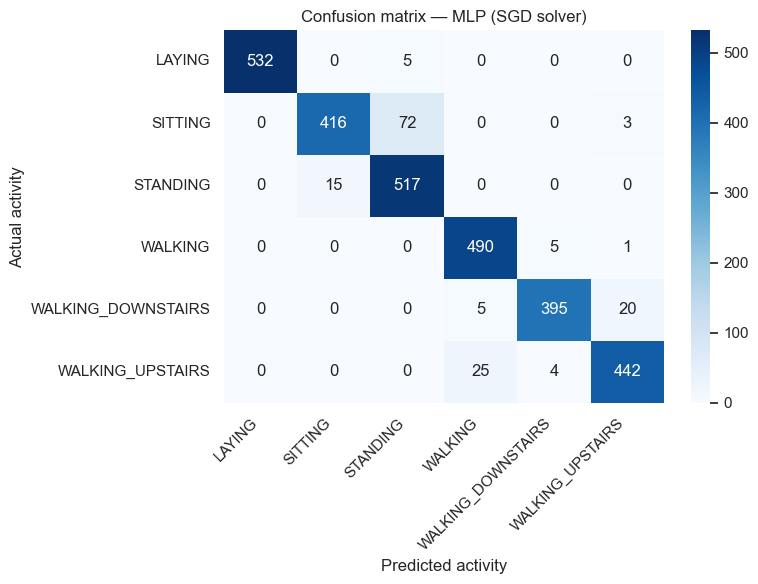

In [13]:
acc_sgd = evaluate_model(mlp_sgd, "SGD")


=== MLP (Adam) ===
Test accuracy: 0.9474

                    precision    recall  f1-score   support

            LAYING       1.00      0.98      0.99       537
           SITTING       0.96      0.90      0.93       491
          STANDING       0.89      0.97      0.93       532
           WALKING       0.91      0.99      0.95       496
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
  WALKING_UPSTAIRS       0.95      0.90      0.93       471

          accuracy                           0.95      2947
         macro avg       0.95      0.95      0.95      2947
      weighted avg       0.95      0.95      0.95      2947



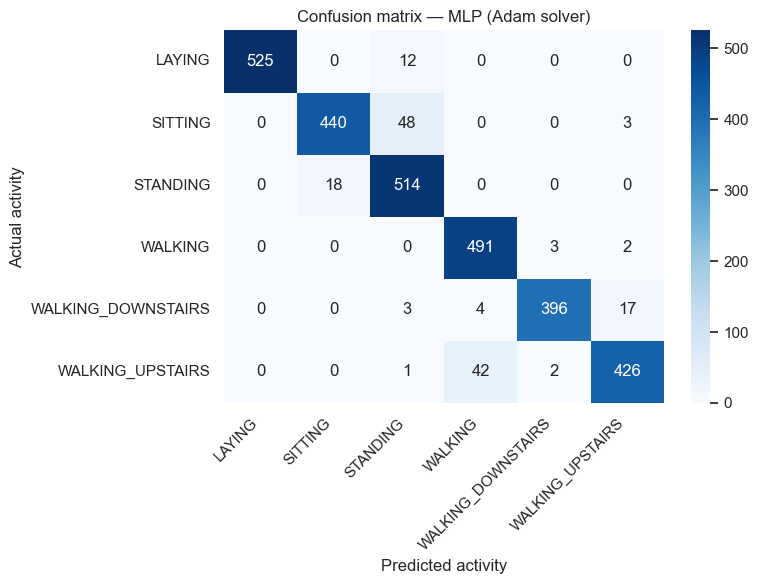

In [14]:
acc_adam = evaluate_model(mlp_adam, "Adam")


In [15]:
print(f"SGD  test accuracy: {acc_sgd:.4f}")
print(f"Adam test accuracy: {acc_adam:.4f}")
print(f"Difference (Adam - SGD): {acc_adam - acc_sgd:+.4f}")


SGD  test accuracy: 0.9474
Adam test accuracy: 0.9474
Difference (Adam - SGD): +0.0000


### SGD vs. Adam

On this run, both optimizers land on the **exact same test accuracy: 94.74%**
(2,792 / 2,947 correct). But they get there very differently:

| | SGD | Adam |
|---|---|---|
| Iterations to stop | 400 (hit the cap) | 186 (converged) |
| Final training loss | 0.0425 | 0.0089 |
| Hit `tol` before `max_iter`? | No | Yes |

Adam converges in under half the iterations SGD is given, to a training
loss almost 5x lower, because its per-parameter adaptive learning rates
make much faster progress than SGD's single fixed learning rate. SGD is
still improving when it hits the 400-iteration cap and never reaches the
`1e-4` convergence tolerance — it would likely close the gap further with
more iterations, but at real training-time cost (its 400 iterations already
took about 2x longer wall-clock time than Adam's 186).

Where the two models *do* differ is which mistakes they make. Both confuse
SITTING and STANDING far more than any other pair of classes — expected,
since those two postures produce very similar accelerometer/gyroscope
signatures — but the split differs: SGD misclassifies 72 SITTING samples as
STANDING and 15 STANDING samples as SITTING (87 of its 155 errors, 56%);
Adam misclassifies 48 SITTING samples as STANDING and 18 the other way (66
of its 155 errors, 42%). Adam also confuses WALKING_UPSTAIRS with WALKING
more often (42 vs. SGD's 25). Both models classify LAYING almost perfectly.

In short: for a fixed accuracy target, Adam gets there faster and with a
tighter fit to the training data, which matches its reputation as the
stronger default optimizer for this kind of feature-vector neural network.
Plain SGD is a reasonable baseline but needs more iterations (and likely a
learning-rate schedule) to compete on training efficiency.


## 6. Conclusion

- A single-hidden-layer MLP (`hidden_layer_sizes=(90,)`) trained on the 561
  pre-computed sensor features reaches **94.74% test accuracy** on held-out
  subjects, for both the SGD-trained and Adam-trained variants.
- **Adam is the more efficient optimizer here.** It converged in 186
  iterations (training loss 0.0089) versus SGD's fixed 400-iteration budget
  (training loss 0.0425, still not converged) — roughly half the iterations
  and about half the wall-clock training time, for the same final accuracy.
- **The dominant error mode for both models is confusing SITTING and
  STANDING** — together they account for over half of all misclassifications
  (56% for SGD, 42% for Adam). This lines up with the EDA: those two are the
  only activities where the raw sensor features (body-acceleration
  magnitude, gravity orientation) don't visibly separate — both are static,
  seated/standing postures with a phone at a similar orientation, so the
  accelerometer/gyroscope signal is genuinely more ambiguous between them
  than it is for, say, LAYING vs. WALKING.
- **LAYING is classified almost perfectly** by both models (99%+
  precision/recall), consistent with it being the activity most visibly
  separated in the EDA stripplots (very different phone orientation from
  every other activity).
- The three walking-related activities (WALKING, WALKING_UPSTAIRS,
  WALKING_DOWNSTAIRS) are distinguished well from the static activities but
  are occasionally confused with each other, which also matches intuition —
  they share the same basic gait signature and differ mainly in the
  vertical acceleration component.
- **Practical takeaway:** for this dataset and model, optimizer choice
  didn't change the accuracy ceiling — the limiting factor is the inherent
  similarity between certain activity pairs (SITTING/STANDING) in the
  feature representation, not the optimizer. Adam is still the better
  default choice for training efficiency and reliability (a clear
  convergence signal via `tol`), which is why it's the more common default
  in practice.

**Possible next steps** (not explored here): grid search over
`hidden_layer_sizes` and `alpha`, feature selection/PCA to reduce the
561-dimensional input, or a model architecture that treats the raw
time-series windows directly (e.g. a 1D-CNN or LSTM on the Inertial Signals
data) rather than the hand-engineered feature vectors used here — plausible
approaches to close the residual SITTING/STANDING gap.
